In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

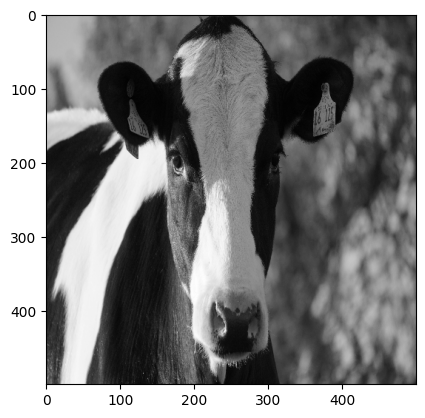

In [2]:
img = cv2.imread('pexels-gammel-23940471.jpg', cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (500, 500))
plt.imshow(img, cmap='gray')

In [3]:
def hough_line(img):
    height, width = img.shape
    maxdist = int(np.round(np.sqrt(height**2 + width**2)))
    rhos = np.linspace(-maxdist, maxdist, maxdist * 2)
    thetas = np.deg2rad(np.arange(-90, 90))
    
    accumulator = np.zeros((len(rhos), len(thetas)), dtype=np.uint64)
    
    y_idxs, x_idxs = np.nonzero(img)  # Get edge points
    for i in range(len(x_idxs)):
        x = x_idxs[i]
        y = y_idxs[i]
        for t_idx in range(len(thetas)):
            theta = thetas[t_idx]
            rho = int(x * np.cos(theta) + y * np.sin(theta)) + maxdist
            accumulator[rho, t_idx] += 1
            
    return accumulator, rhos, thetas

In [4]:
image = np.zeros((150, 150), dtype=np.uint8)
image[50,50] = 1
accumulator, rhos, thetas = hough_line(image)
idx = np.argmax(accumulator)